In [1]:
import numpy as np 
import pandas as pd 
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "/kaggle/input/kunuz-cleaned/kunuz_final.csv"

df = pd.read_csv(file_path)

df = df[df['gender'] != 'unknown']
# not 17620 
len(df)

16154

In [2]:
import os, random, math, numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm

# Config
SEED = 42
BATCH_TRAIN = 32
BATCH_VAL = 32
EPOCHS = 20
LR = 2e-5
MAX_LEN = 512
MODEL_NAME = "elmurod1202/bertbek-news-big-cased"

device = "cuda" if torch.cuda.is_available() else "cpu"
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

tok = AutoTokenizer.from_pretrained(MODEL_NAME)
print('hi')

tokenizer_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

hi


In [6]:
print(df.head())

   Unnamed: 0  author_id                                              title  \
0           0         51  Putin Ramzan Qodirovning iste’foga chiqishiga ...   
1           1         45  Qatar biz uchun noqulay raqib, lekin undan kuc...   
2           2         49  Abduqodir Husanov – «Manchester Siti»ning fevr...   
3           3          4  Kiyev atrofida texnikalar qabristoni, dahshat ...   
5           5          4   Yangibozor tumani hokimi lavozimidan ozod etildi   

  gender     category  year  \
0   male        Jahon  2025   
1   male        Sport  2025   
2   male        Sport  2025   
3   male        Jahon  2022   
5   male  O‘zbekiston  2023   

                                                body  \
0  Checheniston yetakchisi 7 may kuni Vladimir Pu...   
1  Muddatidan oldin jahon chempionati yo‘llanmasi...   
2  O‘zbekiston milliy jamoasi himoyachisi Abduqod...   
3  Ukrainadagi urushning 38 kuni o‘tdi. Kiyev obl...   
5  U – Qahramon Quronboyevning akasi. Foto: Xoraz...   

 

In [3]:
from transformers import DataCollatorWithPadding
from sklearn.preprocessing import LabelEncoder

le_gender = LabelEncoder()
le_age = LabelEncoder()
le_industry = LabelEncoder()

df["gender_lbl"]   = le_gender.fit_transform(df["gender"])
df["year_lbl"] = le_age.fit_transform(df["year"])
df["topic_lbl"]  = le_industry.fit_transform(df["category"])

print(df["gender_lbl"])

# -------- Dataset (no fixed padding here) --------
class MTDataset(Dataset):
    def __init__(self, df, max_len=MAX_LEN):
        self.texts = df["body"].astype(str).tolist()
        self.g = df["gender_lbl"].astype(int).tolist()
        self.y = df["year_lbl"].astype(int).tolist()
        self.t = df["topic_lbl"].astype(int).tolist()
        self.max_len = MAX_LEN
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = tok(
            self.texts[idx],
            truncation=True,
            max_length=self.max_len,   # cap length
            return_tensors="pt"        # <-- no padding="max_length"
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["g"] = torch.tensor(self.g[idx], dtype=torch.float32)
        item["y"] = torch.tensor(self.y[idx], dtype=torch.long)
        item["t"] = torch.tensor(self.t[idx], dtype=torch.long)
        return item

# -------- Dynamic pad collator --------
collate_fn = DataCollatorWithPadding(tokenizer=tok, return_tensors="pt")

# -------- Split (keep your label encoders as you wrote) --------
train_df, val_df = train_test_split(
    df, test_size=0.15, random_state=SEED, stratify=df["gender_lbl"]
)

ds_tr, ds_va = MTDataset(train_df, max_len=MAX_LEN), MTDataset(val_df, max_len=MAX_LEN)

# Use workers + pin_memory for speed
dl_tr = DataLoader(
    ds_tr, batch_size=BATCH_TRAIN, shuffle=True,
    collate_fn=collate_fn, num_workers=4, pin_memory=True, persistent_workers=True
)
dl_va = DataLoader(
    ds_va, batch_size=BATCH_VAL, shuffle=False,
    collate_fn=collate_fn, num_workers=4, pin_memory=True, persistent_workers=True
)


# 1) counts (MUST come first)
year_counts  = df["year_lbl"].value_counts().sort_index()
topic_counts = df["topic_lbl"].value_counts().sort_index()

# 2) number of classes (optional; can also use year_counts.size)
num_year  = df["year_lbl"].nunique()
num_topic = df["topic_lbl"].nunique()

# 3) weights
year_w = year_counts.sum() / (num_year * year_counts)
year_w = torch.tensor(year_w.values, dtype=torch.float)

topic_w = topic_counts.sum() / (num_topic * topic_counts)
topic_w = torch.tensor(topic_w.values, dtype=torch.float)
topic_w = torch.clamp(topic_w, max=10.0)


gender_counts = df["gender_lbl"].value_counts().sort_index()
n_neg = gender_counts[0]   # label 0 (e.g. male)
n_pos = gender_counts[1]   # label 1 (e.g. female)
gender_pos_w = torch.tensor([n_neg / n_pos], dtype=torch.float)

gender_pos_w = gender_pos_w.to(device)
year_w  = year_w.to(device)
topic_w = topic_w.to(device)

2026-01-18 12:10:55.824771: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768738256.142443      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768738256.245425      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768738257.017033      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768738257.017091      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768738257.017094      55 computation_placer.cc:177] computation placer alr

0        1
1        1
2        1
3        1
5        1
        ..
17615    1
17616    1
17617    1
17618    1
17619    1
Name: gender_lbl, Length: 16154, dtype: int64


In [32]:
import torch, torch.nn as nn
from transformers import AutoModel

class MTLModel(nn.Module):
    def __init__(self, model_name, num_year, num_topic):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hid = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(0.1)

        # projections
        self.proj_g = nn.Linear(hid, hid)
        self.proj_y = nn.Linear(hid, hid)
        self.proj_t = nn.Linear(hid, hid)

        # cross-attn blocks
        self.ca_y = nn.MultiheadAttention(embed_dim=hid, num_heads=4, batch_first=True)
        self.ca_t = nn.MultiheadAttention(embed_dim=hid, num_heads=4, batch_first=True)

        # heads
        self.head_g = nn.Linear(hid, 1)
        self.head_y = nn.Linear(hid, num_year)
        self.head_t = nn.Linear(hid, num_topic)

    def forward(self, input_ids, attention_mask, return_emb=False):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        h = self.dropout(out.last_hidden_state[:, 0])  # CLS (B,H)

        # base task reps
        h_g = self.proj_g(h)
        h_y = self.proj_y(h)
        h_t = self.proj_t(h)

        # Year attends to Gender
        qy = h_y.unsqueeze(1)      # (B,1,H)
        kv_g = h_g.unsqueeze(1)    # (B,1,H)
        h_y_ca, _ = self.ca_y(qy, kv_g, kv_g)
        h_y_ca = h_y_ca.squeeze(1)

        # Topic attends to Gender
        qt = h_t.unsqueeze(1)
        h_t_ca, _ = self.ca_t(qt, kv_g, kv_g)
        h_t_ca = h_t_ca.squeeze(1)

        # logits
        lg = self.head_g(h_g).squeeze(1)  # (B,)
        ly = self.head_y(h_y_ca)          # (B, num_year)
        lt = self.head_t(h_t_ca)          # (B, num_topic)

        if return_emb:
            # choose what you want to UMAP: CLS before heads (recommended)
            return (lg, ly, lt), h
        return (lg, ly, lt)

def load_ckpt_into_model(model, ckpt_path, device="cpu"):
    ckpt = torch.load(ckpt_path, map_location=device)
    state = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt

    # If checkpoint keys are "module.xxx" but model isn't wrapped
    if any(k.startswith("module.") for k in state.keys()):
        state = {k.replace("module.", "", 1): v for k, v in state.items()}

    missing, unexpected = model.load_state_dict(state, strict=False)
    print("Loaded checkpoint.")
    if missing:    print("Missing keys:", missing[:10], "... total", len(missing))
    if unexpected: print("Unexpected keys:", unexpected[:10], "... total", len(unexpected))
    return model

In [33]:
device = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_NAME = MODEL_NAME  # keep your variable
num_year   = num_year
num_topic  = num_topic

model = MTLModel(MODEL_NAME, num_year, num_topic).to(device)

ckpt_path = "/kaggle/input/kunuz-imp/bertbek_mtl/bertbek_mtl_epoch25.pt"
model = load_ckpt_into_model(model, ckpt_path, device="cpu")  # load on cpu is fine
model.to(device)
model.eval()

def evaluate_and_collect(dl):
    model.eval()
    g_true, g_pred = [], []
    y_true, y_pred = [], []
    t_true, t_pred = [], []
    embs = []

    with torch.no_grad():
        for batch in dl:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            g = batch["g"].cpu().numpy()
            y = batch["y"].cpu().numpy()
            t = batch["t"].cpu().numpy()

            (lg, ly, lt), h = model(input_ids, attention_mask, return_emb=True)

            g_hat = (torch.sigmoid(lg) >= 0.5).long().cpu().numpy()
            y_hat = ly.argmax(1).cpu().numpy()
            t_hat = lt.argmax(1).cpu().numpy()

            g_true.append(g); g_pred.append(g_hat)
            y_true.append(y); y_pred.append(y_hat)
            t_true.append(t); t_pred.append(t_hat)

            embs.append(h.cpu().numpy())  # (B,H)

    out = {
        "g_true": np.concatenate(g_true),
        "g_pred": np.concatenate(g_pred),
        "y_true": np.concatenate(y_true),
        "y_pred": np.concatenate(y_pred),
        "t_true": np.concatenate(t_true),
        "t_pred": np.concatenate(t_pred),
        "embs":   np.concatenate(embs),  # (N,H)
    }
    return out

out = evaluate_and_collect(dl_va)  # <-- use your test dataloader name

from sklearn.metrics import confusion_matrix

cm_g = confusion_matrix(out["g_true"], out["g_pred"])
cm_y = confusion_matrix(out["y_true"], out["y_pred"])
cm_t = confusion_matrix(out["t_true"], out["t_pred"])

Loaded checkpoint.
Unexpected keys: ['log_sigma_gender', 'log_sigma_year', 'log_sigma_topic', 'bce.pos_weight', 'ce_y.weight', 'ce_t.weight'] ... total 6


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


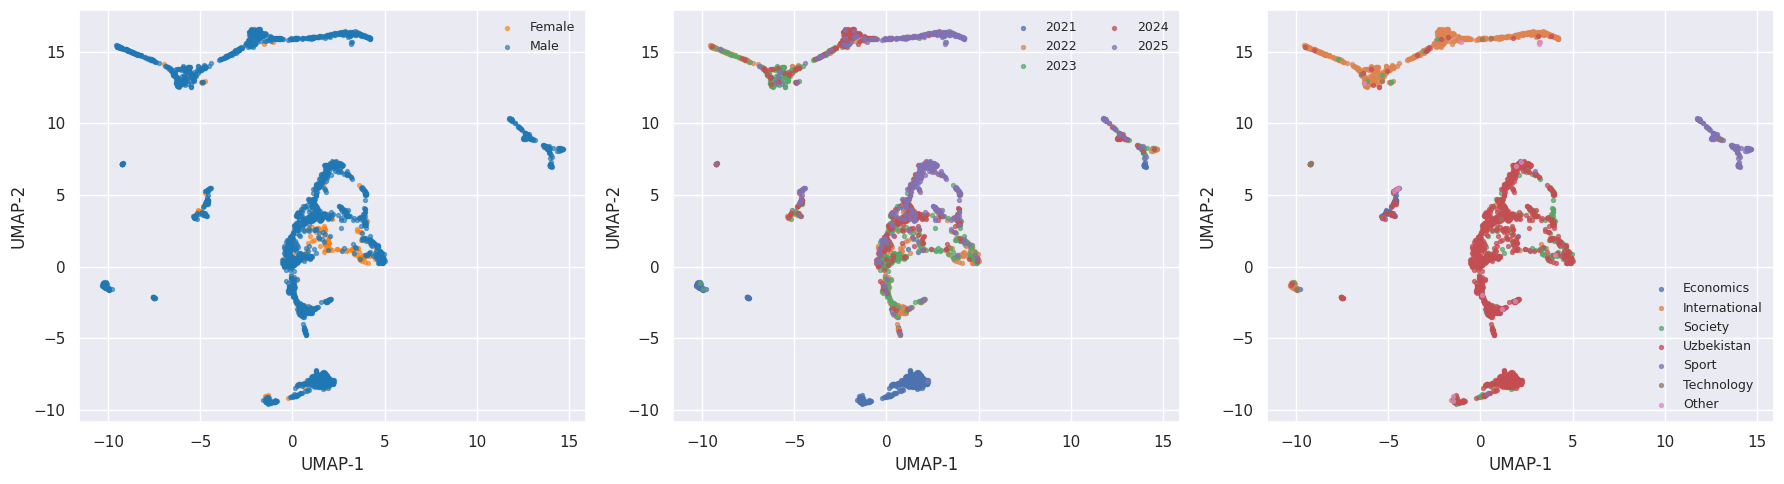

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap

sns.set()

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)
X_2d = reducer.fit_transform(out["embs"])  # (N,2)

gender_map = {0: "Female", 1: "Male"}
gender_colors = {0: "#ff7f0e", 1: "#1f77b4"}  # optional

year_map = {0: "2021", 1: "2022", 2: "2023", 3: "2024", 4: "2025"}

category_map = {
    0: "Economics",
    1: "International",
    2: "Society",
    3: "Uzbekistan",
    4: "Sport",
    5: "Technology",
    6: "Other"
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Gender
ax = axes[0]
for g_id, g_name in gender_map.items():
    idx = out["g_true"] == g_id
    ax.scatter(X_2d[idx, 0], X_2d[idx, 1], s=8, alpha=0.6, label=g_name, color=gender_colors[g_id])
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend(frameon=False, fontsize=9)

# (b) Year
ax = axes[1]
for y_id, y_name in year_map.items():
    idx = out["y_true"] == y_id
    ax.scatter(X_2d[idx, 0], X_2d[idx, 1], s=8, alpha=0.7, label=y_name)
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend(frameon=False, fontsize=9, ncol=2)

# (c) Category
ax = axes[2]
for c_id, c_name in category_map.items():
    idx = out["t_true"] == c_id
    ax.scatter(X_2d[idx, 0], X_2d[idx, 1], s=8, alpha=0.7, label=c_name)
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()

# ✅ SAVE FIRST (important!)
plt.savefig("/kaggle/working/umap_triplet.png", dpi=300, bbox_inches="tight")

# ✅ THEN SHOW
plt.show()
plt.close(fig)

In [54]:
import os
print(os.listdir("/kaggle/working"))

['.virtual_documents', 'confusion_matrices.png', 'umap_triplet.png']


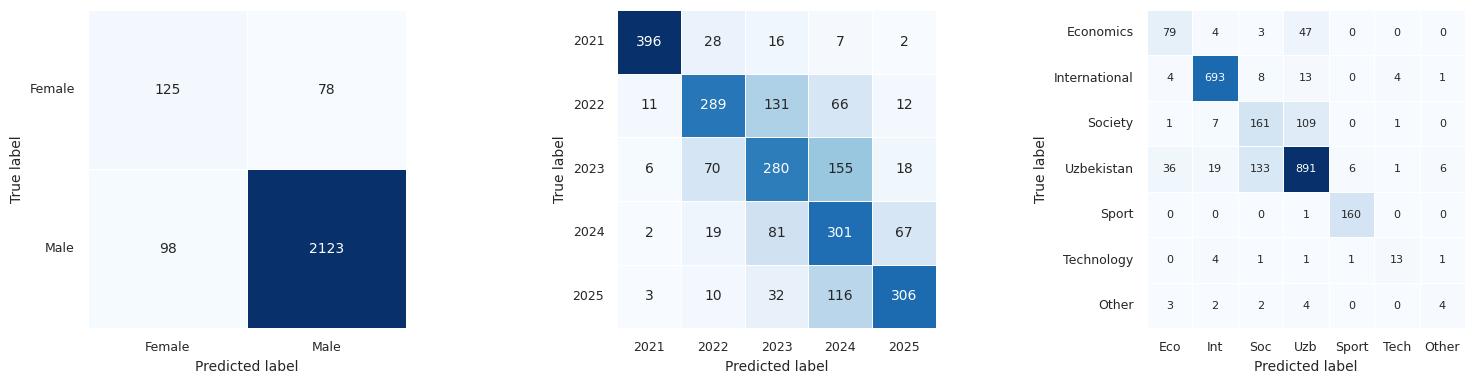

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

sns.set()

gender_names = ["Female", "Male"]

year_names = ["2021", "2022", "2023", "2024", "2025"]

# Topic labels
topic_y_full = [
    "Economics",
    "International",
    "Society",
    "Uzbekistan",
    "Sport",
    "Technology",
    "Other"
]

topic_x_abbrev = ["Eco", "Int", "Soc", "Uzb", "Sport", "Tech", "Other"]


def plot_cm(ax, y_true, y_pred, xlabels, ylabels, title, annot_size=9):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(xlabels)))
    sns.heatmap(
        cm,
        ax=ax,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        square=True,
        linewidths=0.5,
        linecolor="white",
        annot_kws={"size": annot_size}
    )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Predicted label", fontsize=10)
    ax.set_ylabel("True label", fontsize=10)
    ax.set_xticklabels(xlabels, rotation=0, fontsize=9)
    ax.set_yticklabels(ylabels, rotation=0, fontsize=9)
    return cm


fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) Gender
cm_g = plot_cm(
    axes[0],
    out["g_true"], out["g_pred"],
    gender_names,
    gender_names,
    "",
    annot_size=10
)

# (b) Year
cm_y = plot_cm(
    axes[1],
    out["y_true"], out["y_pred"],
    year_names,
    year_names,
    "",
    annot_size=10
)

# (c) Topic (X abbrev, Y full)
cm_t = plot_cm(
    axes[2],
    out["t_true"], out["t_pred"],
    topic_x_abbrev,      # X-axis
    topic_y_full,        # Y-axis
    "",
    annot_size=8
)

plt.tight_layout()

# ✅ SAVE FIRST
plt.savefig("confusion_matrices.png", dpi=300, bbox_inches="tight")

# ✅ THEN SHOW
plt.show()
plt.close(fig)